<a href="https://colab.research.google.com/github/MlPablosky/IA/blob/dataset-corte-3/Copia_de_IA_corte_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime, timedelta

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

In [ ]:
# Número de registros (ventas)
n = 300

# Marcas de pianos
brands = ["Yamaha", "Casio", "Nord", "Kawai", "Roland"]

# Generar datos
data = {
    "sale_id": np.arange(1, n + 1),
    "brand": np.random.choice(brands, size=n, p=[0.32, 0.25, 0.18, 0.15, 0.10]),
    "price_usd": np.round(np.random.normal(loc=3200, scale=900, size=n), 2),
    "units_sold": np.random.poisson(lam=3, size=n),
    "sale_date": [
        datetime(2020, 1, 1) + timedelta(days=int(x))
        for x in np.random.uniform(0, 1400, n)
    ]
}

df = pd.DataFrame(data)
# Evitar precios negativos o muy bajos
df["price_usd"] = df["price_usd"].clip(lower=500)

# Mostrar los primeros registros
df.head(10)


,sale_id,brand,price_usd,units_sold,sale_date
0,1,Casio,3241.01,2,2022-10-23
1,2,Roland,2613.56,1,2022-05-12
2,3,Nord,5129.55,1,2020-09-20
3,4,Nord,3770.53,4,2021-05-12
4,5,Yamaha,1377.37,4,2023-01-02
5,6,Yamaha,3367.81,6,2022-02-14
6,7,Yamaha,2604.39,1,2020-01-08
7,8,Kawai,3967.19,4,2022-12-01
8,9,Nord,2486.73,1,2020-02-19
9,10,Nord,3096.74,5,2022-11-10


In [ ]:
df["price_usd"].describe()


,price_usd
count,300.000000
mean,3187.931867
std,888.890530
min,500.000000
25%,2546.640000
50%,3186.160000
75%,3771.580000
max,5970.990000


In [ ]:
mean_price = df["price_usd"].mean()
median_price = df["price_usd"].median()
mode_price = df["price_usd"].mode()[0]

print(f"Media: {mean_price:.2f}")
print(f"Mediana: {median_price:.2f}")
print(f"Moda: {mode_price:.2f}")


Media: 3187.93
Mediana: 3186.16
Moda: 500.00


In [ ]:
variance = df["price_usd"].var()
std_dev = df["price_usd"].std()
iqr = stats.iqr(df["price_usd"])
price_range = df["price_usd"].max() - df["price_usd"].min()
mad = (df["price_usd"] - df["price_usd"].mean()).abs().mean()

print(f"Varianza: {variance:.2f}")
print(f"Desviación Estándar: {std_dev:.2f}")
print(f"IQR (Rango intercuartílico): {iqr:.2f}")
print(f"Rango (máx - mín): {price_range:.2f}")
print(f"Desviación Media Absoluta: {mad:.2f}")

Varianza: 790126.37
Desviación Estándar: 888.89
IQR (Rango intercuartílico): 1224.94
Rango (máx - mín): 5470.99
Desviación Media Absoluta: 713.20


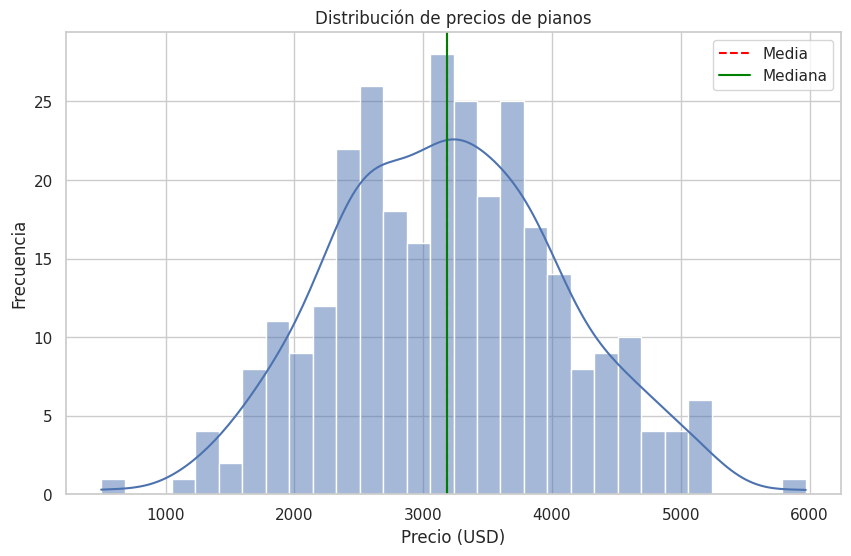

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma con KDE
sns.histplot(df["price_usd"], kde=True, bins=30)

plt.axvline(mean_price, color="red", linestyle="--", label="Media")
plt.axvline(median_price, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de precios de pianos")
plt.xlabel("Precio (USD)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


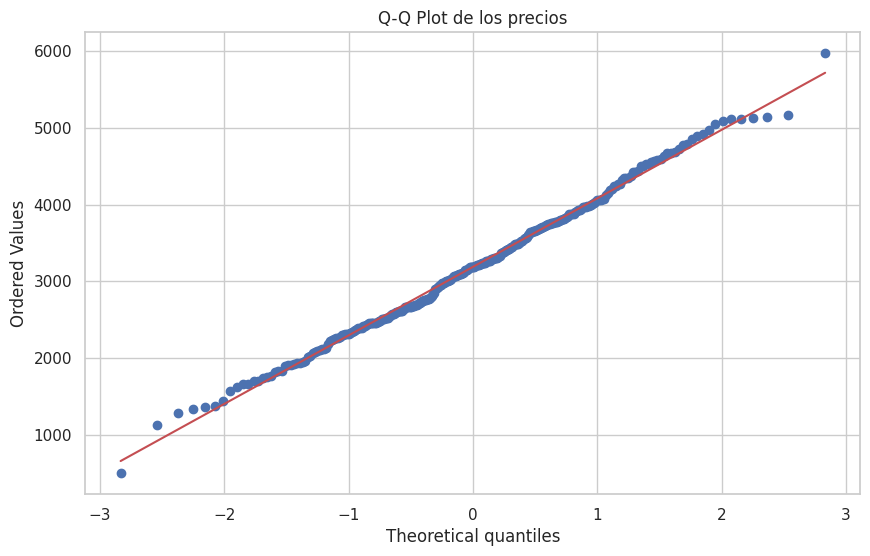

In [ ]:
stats.probplot(df["price_usd"], dist="norm", plot=plt)
plt.title("Q-Q Plot de los precios")
plt.show()


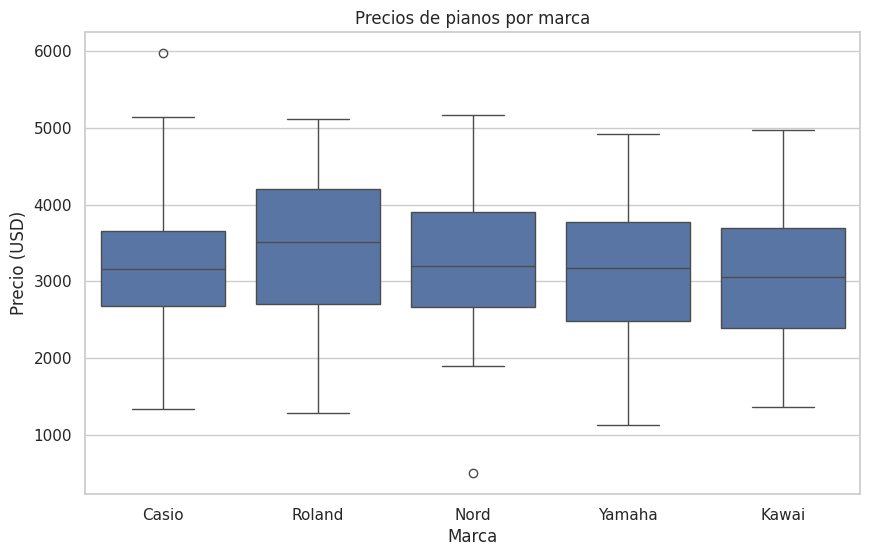

In [ ]:
sns.boxplot(data=df, x="brand", y="price_usd")
plt.title("Precios de pianos por marca")
plt.xlabel("Marca")
plt.ylabel("Precio (USD)")
plt.show()


In [ ]:
cv_brand = (df.groupby("brand")["price_usd"].std()
            / df.groupby("brand")["price_usd"].mean())
cv_brand = cv_brand.reset_index().rename(columns={"price_usd": "coef_variación"})
cv_brand


,brand,coef_variación
0,Casio,0.268784
1,Kawai,0.285139
2,Nord,0.284332
3,Roland,0.280169
4,Yamaha,0.275372


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['coef_variación'].plot(kind='hist', bins=20, title='coef_variación')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('brand').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='index', y='coef_variación', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7['coef_variación'].plot(kind='line', figsize=(8, 4), title='coef_variación')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['brand'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='index', y='brand', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_9['brand'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_9, x='coef_variación', y='brand', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
skewness = stats.skew(df["price_usd"])
kurtosis = stats.kurtosis(df["price_usd"], fisher=True)  # kurtosis de Fisher

print(f"Asimetría (skew): {skewness:.3f}")
print(f"Curtosis (Fisher): {kurtosis:.3f}")


Asimetría (skew): 0.120
Curtosis (Fisher): -0.152
